In [2]:
# Тестирование модели intfloat/multilingual-e5-small
## Эксперимент 1: Оценка качества ретрива (Hit Rate@5)

In [3]:
!pip install sentence-transformers faiss-cpu pandas numpy tqdm matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 42.7 MB/s eta 0:00:00


In [4]:
import json
import numpy as np
from sentence_transformers import SentenceTransformer
import faiss
from tqdm import tqdm
import re
import matplotlib.pyplot as plt

In [5]:
with open('fcs_hse_qa_dataset.json', 'r', encoding='utf-8') as f:
    qa_data = json.load(f)

print(f"Загружено {len(qa_data)} вопросов")
print("\nПример вопроса:")
print(json.dumps(qa_data[0], ensure_ascii=False, indent=2))

Загружено 50 вопросов

Пример вопроса:
{
  "id": 1,
  "question": "Какие программы бакалавриата есть на ФКН ВШЭ?",
  "answer": "На Факультете компьютерных наук НИУ ВШЭ есть следующие программы бакалавриата: Прикладная математика и информатика (ПМИ), Программная инженерия (ПИ), Компьютерные науки и анализ данных (КНАД), Информационная безопасность (ИБ), а также совместный бакалавриат ВШЭ и ЦПМ.",
  "context": "Программы бакалавриата ФКН НИУ ВШЭ",
  "category": "программы"
}


In [6]:
with open('text.txt', 'r', encoding='utf-8') as f:
    full_text = f.read()

print(f"Загружено {len(full_text)} символов текста")
print("\nПервые 500 символов:")
print(full_text[:500])

Загружено 217758 символов текста

Первые 500 символов:


Мы используем файлы cookies для улучшения работы сайта НИУ ВШЭ и большего удобства его использования. Более подробную информацию об использовании файлов cookies можно найти здесь, наши правила обработки персональных данных – здесь. Продолжая пользоваться сайтом, вы подтверждаете, что были проинформированы об использовании файлов cookies сайтом НИУ ВШЭ и согласны с нашими правилами обработки персональных данных. Вы можете отключить файлы cookies в настройках Вашего браузера.
✖

    RUEN

    На


In [7]:
def clean_text(text):
    """Очистка текста от лишних символов"""
    text = re.sub(r'\n\s*\n', '\n\n', text)
    text = re.sub(r' +', ' ', text)
    return text.strip()

def split_into_chunks(text, chunk_size=500, overlap=50):
    """
    Разбивает текст на чанки заданного размера с перекрытием
    """
    text = clean_text(text)
    chunks = []

    sentences = re.split(r'(?<=[.!?])\s+', text)

    current_chunk = ""
    for sentence in sentences:
        if len(sentence) > chunk_size:
            for i in range(0, len(sentence), chunk_size - overlap):
                chunk = sentence[i:i + chunk_size]
                if chunk:
                    chunks.append(chunk)
            continue

        if len(current_chunk) + len(sentence) < chunk_size:
            current_chunk += " " + sentence
        else:

            if current_chunk:
                chunks.append(current_chunk.strip())
            if len(current_chunk) > overlap:
                current_chunk = current_chunk[-overlap:] + " " + sentence
            else:
                current_chunk = sentence


    if current_chunk:
        chunks.append(current_chunk.strip())

    return chunks

In [8]:

CHUNK_SIZE = 500
OVERLAP = 50


chunks = split_into_chunks(full_text, chunk_size=CHUNK_SIZE, overlap=OVERLAP)
print(f"Создано {len(chunks)} чанков")
print("\nПример чанка:")
print(chunks[0][:200] + "...")

Создано 560 чанков

Пример чанка:
Мы используем файлы cookies для улучшения работы сайта НИУ ВШЭ и большего удобства его использования. Более подробную информацию об использовании файлов cookies можно найти здесь, наши правила обработ...


In [9]:

with open('chunks.txt', 'w', encoding='utf-8') as f:
    for i, chunk in enumerate(chunks):
        f.write(f"[ЧАНК {i}]\n{chunk}\n{'-'*50}\n")

print("Чанки сохранены в chunks.txt")

Чанки сохранены в chunks.txt


In [10]:

model_name = 'intfloat/multilingual-e5-small'
print(f"Загрузка модели {model_name}...")
model = SentenceTransformer(model_name)
print("Модель загружена!")

Загрузка модели intfloat/multilingual-e5-small...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/443 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

Модель загружена!


In [11]:

print("Векторизация чанков...")
chunk_embeddings = model.encode(chunks, show_progress_bar=True)
print(f"Создано {len(chunk_embeddings)} эмбеддингов размерностью {chunk_embeddings.shape[1]}")

Векторизация чанков...


Batches:   0%|          | 0/18 [00:00<?, ?it/s]

Создано 560 эмбеддингов размерностью 384


In [12]:
dimension = chunk_embeddings.shape[1]
index = faiss.IndexFlatL2(dimension)
index.add(chunk_embeddings.astype('float32'))
print(f"Индекс FAISS создан. Количество векторов: {index.ntotal}")

Индекс FAISS создан. Количество векторов: 560


In [13]:
def find_relevant_chunks(question, model, index, chunks, k=5):
    """
    Находит k наиболее релевантных чанков для вопроса
    """
    question_embedding = model.encode([question])

    distances, indices = index.search(question_embedding.astype('float32'), k)

    return indices[0], distances[0]

In [14]:

results = []

for item in tqdm(qa_data, desc="Обработка вопросов"):
    question = item['question']
    correct_answer = item['answer']


    indices, distances = find_relevant_chunks(question, model, index, chunks, k=5)


    found_chunks = [chunks[i] for i in indices]

    answer_keywords = set(correct_answer.lower().split()[:5])
    is_relevant = False

    for chunk in found_chunks:
        chunk_lower = chunk.lower()

        keyword_matches = sum(1 for word in answer_keywords if word in chunk_lower)
        if keyword_matches >= 2:
            is_relevant = True
            break

    results.append({
        'id': item['id'],
        'question': question,
        'correct_answer': correct_answer,
        'found_chunks_indices': indices.tolist(),
        'found_chunks': found_chunks,
        'distances': distances.tolist(),
        'is_relevant': is_relevant
    })

Обработка вопросов: 100%|██████████| 50/50 [00:02<00:00, 19.06it/s]


In [15]:
# Hit Rate@5
total_questions = len(results)
relevant_count = sum(1 for r in results if r['is_relevant'])
hit_rate = relevant_count / total_questions * 100

print(f"\n{'='*50}")
print(f"РЕЗУЛЬТАТЫ ТЕСТИРОВАНИЯ")
print(f"{'='*50}")
print(f"Модель: {model_name}")
print(f"Размер чанка: {CHUNK_SIZE}")
print(f"Перекрытие: {OVERLAP}")
print(f"{'='*50}")
print(f"Всего вопросов: {total_questions}")
print(f"Найдено релевантных: {relevant_count}")
print(f"Hit Rate@5: {hit_rate:.2f}%")
print(f"{'='*50}")


РЕЗУЛЬТАТЫ ТЕСТИРОВАНИЯ
Модель: intfloat/multilingual-e5-small
Размер чанка: 500
Перекрытие: 50
Всего вопросов: 50
Найдено релевантных: 40
Hit Rate@5: 80.00%


In [16]:
print("\n" + "="*50)
print("ПРИМЕРЫ УСПЕШНОГО ПОИСКА")
print("="*50)

successful = [r for r in results if r['is_relevant']][:3]
for i, r in enumerate(successful, 1):
    print(f"\n{i}. Вопрос: {r['question']}")
    print(f"   Правильный ответ: {r['correct_answer'][:100]}...")
    print(f"   Найденный чанк (лучший): {r['found_chunks'][0][:200]}...")


ПРИМЕРЫ УСПЕШНОГО ПОИСКА

1. Вопрос: Какие программы бакалавриата есть на ФКН ВШЭ?
   Правильный ответ: На Факультете компьютерных наук НИУ ВШЭ есть следующие программы бакалавриата: Прикладная математика...
   Найденный чанк (лучший): авку (Приложение № 4 или № 5) в учебном офисе ФКН. Явиться во «Второй отдел» НИУ ВШЭ для оформления отсрочки. Примечание: Поступившие в магистратуру не могут претендовать на военную кафедрутак как отб...

2. Вопрос: Какие ЕГЭ нужно сдавать для поступления на ПМИ?
   Правильный ответ: Для поступления на программу «Прикладная математика и информатика» (ПМИ) необходимо сдать ЕГЭ по мат...
   Найденный чанк (лучший): рные возможности есть у выпускников программы ПМИ? Немало выпускников выбирают исследовательскую карьеру и продолжают обучение в магистратуре или на совместных треках магистратура-аспирантура. Причём ...

3. Вопрос: Когда начинается приём документов в ВШЭ в 2026 году?
   Правильный ответ: Приём документов начинается 20 июня 2026 года....
   Най

In [17]:
print("\n" + "="*50)
print("ПРИМЕРЫ НЕУДАЧНОГО ПОИСКА")
print("="*50)

failed = [r for r in results if not r['is_relevant']]
if failed:
    for i, r in enumerate(failed[:3], 1):
        print(f"\n{i}. Вопрос: {r['question']}")
        print(f"   Правильный ответ: {r['correct_answer'][:100]}...")
        print(f"   Найденный чанк (лучший): {r['found_chunks'][0][:200]}...")
else:
    print("Неудачных поисков нет!")


ПРИМЕРЫ НЕУДАЧНОГО ПОИСКА

1. Вопрос: Можно ли поступить в ВШЭ без вступительных экзаменов?
   Правильный ответ: Да. Победители и призёры заключительного этапа Всероссийской олимпиады школьников, а также члены сбо...
   Найденный чанк (лучший): йн через Личный кабинет абитуриента или Госуслуги. Я хочу перепоступить в ВШЭ, но являюсь студентом бюджетного отделения другого вуза. Могу ли я поступать на бюджетное место? Абитуриент может поступат...

2. Вопрос: Какие олимпиады дают право на бесплатное обучение на коммерческом месте в ВШЭ?
   Правильный ответ: К таким олимпиадам относятся: Всероссийский кейс-чемпионат «Ключ», Всероссийский чемпионат «Своими с...
   Найденный чанк (лучший): льтаты ЕГЭ по русскому языку, математике и физике. Результаты по информатике не будут учитываться. Какие олимпиады могут помочь поступить? Особые права, предоставляемые победителям и призерам олимпиад...

3. Вопрос: Куда обратиться с вопросами по поступлению на ФКН?
   Правильный ответ: По вопросам поступ

In [18]:
with open('results_e5_small.json', 'w', encoding='utf-8') as f:
    simplified_results = []
    for r in results:
        simplified_results.append({
            'id': r['id'],
            'question': r['question'],
            'is_relevant': r['is_relevant'],
            'distances': r['distances']
        })
    json.dump(simplified_results, f, ensure_ascii=False, indent=2)

print("Результаты сохранены в results_e5_small.json")

Результаты сохранены в results_e5_small.json


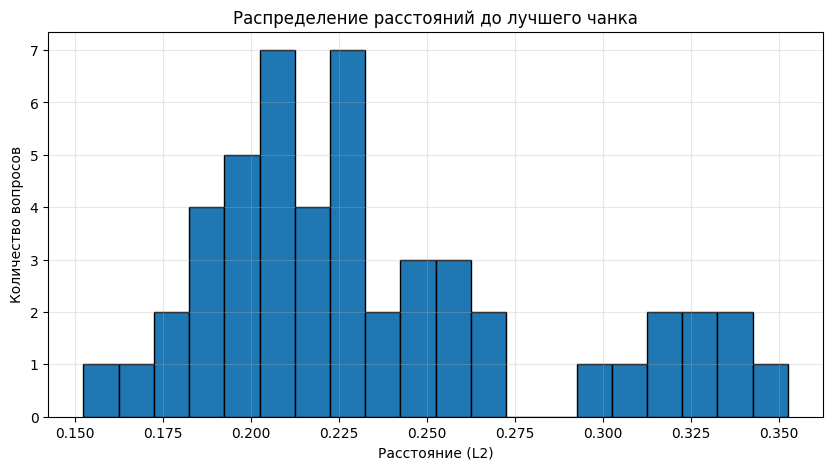

Среднее расстояние: 0.24
Медианное расстояние: 0.22
Мин расстояние: 0.15
Макс расстояние: 0.35


In [19]:

all_distances = [d[0] for d in [r['distances'] for r in results]]

plt.figure(figsize=(10, 5))
plt.hist(all_distances, bins=20, edgecolor='black')
plt.title('Распределение расстояний до лучшего чанка')
plt.xlabel('Расстояние (L2)')
plt.ylabel('Количество вопросов')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Среднее расстояние: {np.mean(all_distances):.2f}")
print(f"Медианное расстояние: {np.median(all_distances):.2f}")
print(f"Мин расстояние: {np.min(all_distances):.2f}")
print(f"Макс расстояние: {np.max(all_distances):.2f}")

In [20]:
print("Эксперимент завершен!")
print(f"Итоговый Hit Rate@5: {hit_rate:.2f}%")

Эксперимент завершен!
Итоговый Hit Rate@5: 80.00%


In [21]:
# paraphrase-multilingual-MiniLM-L12-v2
model_name2 = 'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2'
print(f"Загрузка модели {model_name2}...")
model2 = SentenceTransformer(model_name2)
print("Модель загружена!")

print("Векторизация чанков...")
chunk_embeddings2 = model2.encode(chunks, show_progress_bar=True)
print(f"Создано {len(chunk_embeddings2)} эмбеддингов")
index2 = faiss.IndexFlatL2(chunk_embeddings2.shape[1])
index2.add(chunk_embeddings2.astype('float32'))

results2 = []
for item in tqdm(qa_data, desc="Обработка вопросов"):
    question = item['question']
    correct_answer = item['answer']

    indices, distances = find_relevant_chunks(question, model2, index2, chunks, k=5)
    found_chunks = [chunks[i] for i in indices]

    answer_keywords = set(correct_answer.lower().split()[:5])
    is_relevant = False
    for chunk in found_chunks:
        chunk_lower = chunk.lower()
        keyword_matches = sum(1 for word in answer_keywords if word in chunk_lower)
        if keyword_matches >= 2:
            is_relevant = True
            break

    results2.append(is_relevant)

hit_rate2 = sum(results2) / len(results2) * 100
print(f"\n{'='*50}")
print(f"Модель: {model_name2}")
print(f"Hit Rate@5: {hit_rate2:.2f}%")
print(f"{'='*50}")

Загрузка модели sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

Модель загружена!
Векторизация чанков...


Batches:   0%|          | 0/18 [00:00<?, ?it/s]

Создано 560 эмбеддингов


Обработка вопросов: 100%|██████████| 50/50 [00:03<00:00, 14.67it/s]


Модель: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Hit Rate@5: 78.00%


In [22]:
# cointegrated/rubert-tiny2
model_name3 = 'cointegrated/rubert-tiny2'
print(f"Загрузка модели {model_name3}...")
model3 = SentenceTransformer(model_name3)
print("Модель загружена!")


print("Векторизация чанков...")
chunk_embeddings3 = model3.encode(chunks, show_progress_bar=True)
print(f"Создано {len(chunk_embeddings3)} эмбеддингов")
index3 = faiss.IndexFlatL2(chunk_embeddings3.shape[1])
index3.add(chunk_embeddings3.astype('float32'))
results3 = []
for item in tqdm(qa_data, desc="Обработка вопросов"):
    question = item['question']
    correct_answer = item['answer']

    indices, distances = find_relevant_chunks(question, model3, index3, chunks, k=5)
    found_chunks = [chunks[i] for i in indices]

    answer_keywords = set(correct_answer.lower().split()[:5])
    is_relevant = False
    for chunk in found_chunks:
        chunk_lower = chunk.lower()
        keyword_matches = sum(1 for word in answer_keywords if word in chunk_lower)
        if keyword_matches >= 2:
            is_relevant = True
            break

    results3.append(is_relevant)
hit_rate3 = sum(results3) / len(results3) * 100
print(f"\n{'='*50}")
print(f"Модель: {model_name3}")
print(f"Hit Rate@5: {hit_rate3:.2f}%")
print(f"{'='*50}")

Загрузка модели cointegrated/rubert-tiny2...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/693 [00:00<?, ?B/s]

...

Модель загружена!
Векторизация чанков...


Batches:   0%|          | 0/18 [00:00<?, ?it/s]

Создано 560 эмбеддингов


Обработка вопросов: 100%|██████████| 50/50 [00:00<00:00, 79.64it/s]


Модель: cointegrated/rubert-tiny2
Hit Rate@5: 68.00%


In [24]:
print("\n" + "="*60)
print("СРАВНЕНИЕ МОДЕЛЕЙ")
print("="*60)
print(f"1. intfloat/multilingual-e5-small: {hit_rate:.2f}%")
print(f"2. paraphrase-multilingual-MiniLM-L12-v2: {hit_rate2:.2f}%")
print(f"3. cointegrated/rubert-tiny2: {hit_rate3:.2f}%")
print("="*60)

best_model = max([(hit_rate, "e5-small"), (hit_rate2, "MiniLM"), (hit_rate3, "rubert-tiny2")])
print(f"\nBest model: {best_model[1]} with result {best_model[0]:.2f}%")


СРАВНЕНИЕ МОДЕЛЕЙ
1. intfloat/multilingual-e5-small: 80.00%
2. paraphrase-multilingual-MiniLM-L12-v2: 78.00%
3. cointegrated/rubert-tiny2: 68.00%

Best model: e5-small with result 80.00%
